### 서울시 교통사고 시각화

In [1]:
import pandas as pd
import folium

In [2]:
# Data 불러오기
traffic_seoul = pd.read_csv("../Data/Seoul_2005_2025.csv")
traffic_seoul.head()

,년도,월,자치구명,발생건수,사망자수,부상자수
0,2005,1,강남구,212,2,330
1,2005,1,강동구,101,4,138
2,2005,1,강북구,88,0,142
3,2005,1,강서구,128,0,210
4,2005,1,관악구,97,1,135


In [3]:
traffic_seoul.tail()

,년도,월,자치구명,발생건수,사망자수,부상자수
6295,2025,12,용산구,92,1,119
6296,2025,12,은평구,94,1,110
6297,2025,12,종로구,79,2,96
6298,2025,12,중구,88,0,112
6299,2025,12,중랑구,101,1,122


In [4]:
traffic_seoul.shape

(6300, 6)

In [5]:
traffic_seoul.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6300 entries, 0 to 6299
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   년도      6300 non-null   int64 
 1   월       6300 non-null   int64 
 2   자치구명    6300 non-null   object
 3   발생건수    6300 non-null   int64 
 4   사망자수    6300 non-null   int64 
 5   부상자수    6300 non-null   int64 
dtypes: int64(5), object(1)
memory usage: 295.4+ KB


---
#### 컬럼별 데이터 확인

In [6]:
# 년도 : 2005 ~ 2025
traffic_seoul.년도.unique()

array([2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015,
       2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025])

In [7]:
# 년도별 빈도수 확인
traffic_seoul.년도.value_counts()

년도
2005    300
2016    300
2024    300
2023    300
2022    300
2021    300
2020    300
2019    300
2018    300
2017    300
2015    300
2006    300
2014    300
2013    300
2012    300
2011    300
2010    300
2009    300
2008    300
2007    300
2025    300
Name: count, dtype: int64

In [8]:
# 월별 빈도수 확인
traffic_seoul.월.value_counts()

월
1     525
2     525
3     525
4     525
5     525
6     525
7     525
8     525
9     525
10    525
11    525
12    525
Name: count, dtype: int64

In [9]:
# 자치구명
traffic_seoul.자치구명.value_counts()

자치구명
강남구     252
서대문구    252
중구      252
종로구     252
은평구     252
용산구     252
영등포구    252
양천구     252
송파구     252
성북구     252
성동구     252
서초구     252
마포구     252
강동구     252
동작구     252
동대문구    252
도봉구     252
노원구     252
금천구     252
구로구     252
광진구     252
관악구     252
강서구     252
강북구     252
중랑구     252
Name: count, dtype: int64

----
#### 자치구명별 발생건수


In [10]:
traffic_seoul.head()

,년도,월,자치구명,발생건수,사망자수,부상자수
0,2005,1,강남구,212,2,330
1,2005,1,강동구,101,4,138
2,2005,1,강북구,88,0,142
3,2005,1,강서구,128,0,210
4,2005,1,관악구,97,1,135


In [11]:
# 자치구명별 발생건수의 평균을 데이터프레임으로 작성
regionAcc_mean = \
    traffic_seoul.groupby(
        '자치구명', as_index=False
    )['발생건수'].mean()
regionAcc_mean.head()

,자치구명,발생건수
0,강남구,302.515873
1,강동구,115.440476
2,강북구,97.662698
3,강서구,144.134921
4,관악구,127.793651


In [12]:
# 발생건수 기준으로 내림차순 정렬
regionAcc_mean.sort_values(
    by='발생건수',
    ascending=False
).head(10)

,자치구명,발생건수
0,강남구,302.515873
17,송파구,217.964286
19,영등포구,185.134921
14,서초구,176.428571
10,동대문구,144.511905
3,강서구,144.134921
24,중랑구,138.107143
8,노원구,128.678571
4,관악구,127.793651
12,마포구,127.420635


In [13]:
# 자치구별 발생건수의 표준편차
regionAcc_std = \
    traffic_seoul.groupby(
        '자치구명', as_index=False
    )['발생건수'].std()

regionAcc_std


,자치구명,발생건수
0,강남구,37.170166
1,강동구,19.146334
2,강북구,17.817840
3,강서구,21.464639
4,관악구,27.464811
5,광진구,31.251072
6,구로구,17.680977
7,금천구,14.185473
8,노원구,20.133515
9,도봉구,18.282750


In [14]:
# 발생건수 편차 기준으로 내림차순 정렬
regionAcc_std.sort_values(
    by='발생건수',
    ascending=False
)

,자치구명,발생건수
0,강남구,37.170166
5,광진구,31.251072
14,서초구,28.476433
17,송파구,27.982969
24,중랑구,27.686787
4,관악구,27.464811
12,마포구,25.873383
22,종로구,25.089492
21,은평구,24.654235
10,동대문구,24.470729


In [15]:
# 자치구별 발생건수의 변동 계수
# 변동계수 = 표준편차 / 평균

regionAcc_cv = regionAcc_std.발생건수 / regionAcc_mean.발생건수
regionAcc_cv

0     0.122870
1     0.165855
2     0.182443
3     0.148920
4     0.214915
5     0.306383
6     0.145951
7     0.185768
8     0.156464
9     0.266886
10    0.169334
11    0.173420
12    0.203055
13    0.169144
14    0.161405
15    0.164261
16    0.185312
17    0.128383
18    0.166798
19    0.131980
20    0.195432
21    0.236312
22    0.242736
23    0.226531
24    0.200473
Name: 발생건수, dtype: float64

In [16]:
# 자치구명과 변동계수를 가진 DataFrame 만들기
regionAcc = pd.DataFrame(
        {
            '자치구명' : regionAcc_mean.자치구명,
            '변동계수' : regionAcc_cv
        }
)
regionAcc.head()

,자치구명,변동계수
0,강남구,0.122870
1,강동구,0.165855
2,강북구,0.182443
3,강서구,0.148920
4,관악구,0.214915


In [17]:
# 정렬하여 변동계수가 낮은 지역부터 출력 (Top 10)
regionAcc.sort_values(
    by='변동계수',
    ascending=True
).head(10)

,자치구명,변동계수
0,강남구,0.122870
17,송파구,0.128383
19,영등포구,0.131980
6,구로구,0.145951
3,강서구,0.148920
8,노원구,0.156464
14,서초구,0.161405
15,성동구,0.164261
1,강동구,0.165855
18,양천구,0.166798


---
#### 자치구별 부상자수의 변동계수 구하기

In [18]:
# 자치구별 부상자수의 평균
regionInjure_mean = \
    traffic_seoul.groupby(
        '자치구명', as_index=False
    )['부상자수'].mean()

# 자치구별 부상자수의 표준편차
regionInjure_std = \
    traffic_seoul.groupby(
        '자치구명', as_index=False
    )['부상자수'].std()

# 변동계수
regionInjure_cv = regionInjure_std.부상자수 / regionInjure_mean.부상자수

# 변동계수 DataFrame
regionInjure = pd.DataFrame(
    {
        '자치구명' : regionInjure_mean.자치구명,
        '변동계수' : regionInjure_cv
    }
)

# 정렬하여 부상자수가 높은 지역부터 출력
regionInjure.sort_values(
    by='변동계수',
    ascending=True
)


,자치구명,변동계수
0,강남구,0.119360
17,송파구,0.133559
19,영등포구,0.150313
3,강서구,0.167630
14,서초구,0.173691
8,노원구,0.174668
6,구로구,0.179778
11,동작구,0.181435
18,양천구,0.182976
15,성동구,0.184243


In [19]:
# 교통사고 발생건수와 부상자수의 상관계수
traffic_seoul.발생건수.corr(traffic_seoul.부상자수)

np.float64(0.9801643167014666)

In [20]:
# 교통사고 발생건수와 사망자수의 상관계수
traffic_seoul.발생건수.corr(traffic_seoul.사망자수)

np.float64(0.25140433003751667)

In [21]:
# 교통사고 부상자수와 사망자수의 상관계수
traffic_seoul.부상자수.corr(traffic_seoul.사망자수)

np.float64(0.26056986009030636)

In [22]:
# 자치구별 사망자수의 평균
regionDeath_mean = \
    traffic_seoul.groupby(
        '자치구명', as_index=False
    )['사망자수'].mean()

# 자치구별 사망자수의 표준편차
regionDeath_std = \
    traffic_seoul.groupby(
        '자치구명', as_index=False
    )['사망자수'].std()

# 변동계수
regionDeath_cv = regionDeath_std.사망자수 / regionDeath_mean.사망자수

# 변동계수 DataFrame
regionDeath = pd.DataFrame(
    {
        '자치구명' : regionDeath_mean.자치구명,
        '변동계수' : regionDeath_cv
    }
)

# 정렬하여 사망자수가 높은 지역부터 출력
regionDeath.sort_values(
    by='변동계수',
    ascending=True
)


,자치구명,변동계수
19,영등포구,0.790683
0,강남구,0.822963
17,송파구,0.845154
1,강동구,0.865989
4,관악구,0.886767
3,강서구,0.906104
14,서초구,0.943892
20,용산구,0.961631
10,동대문구,0.982689
22,종로구,0.995078


---
### 시각화

In [23]:
import matplotlib.pyplot as plt
import koreanize_matplotlib

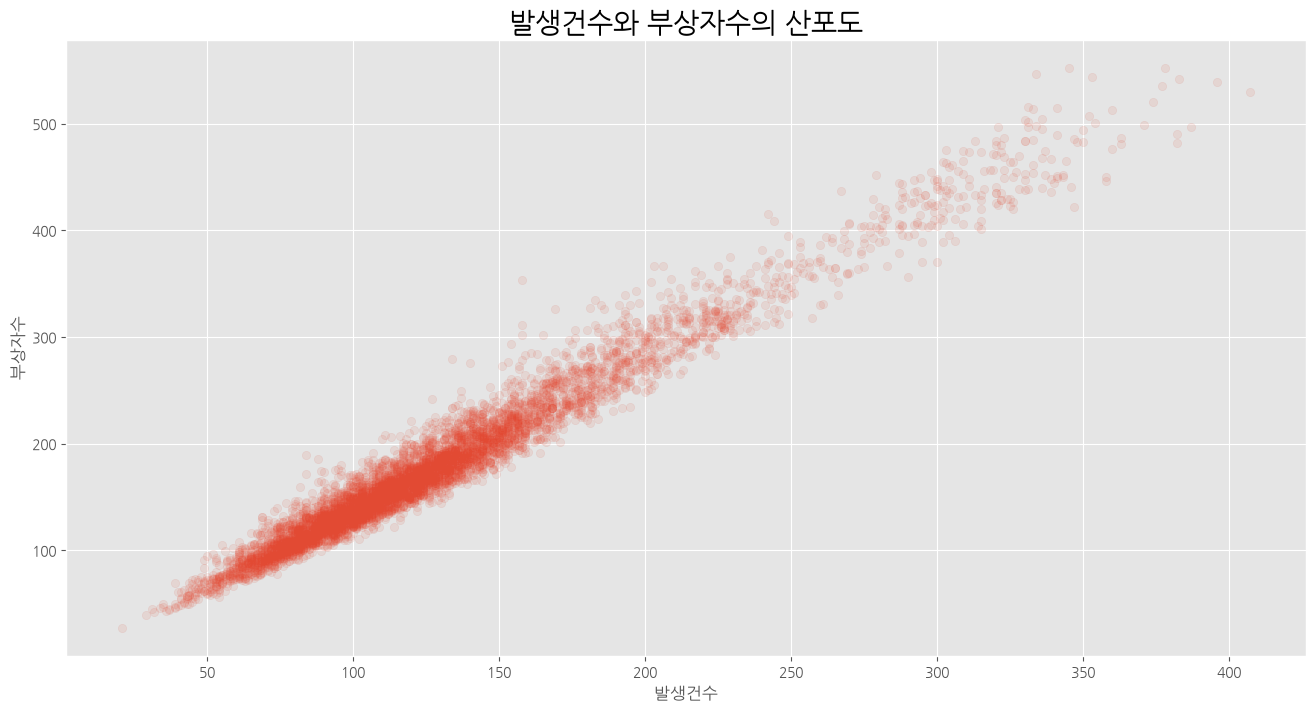

In [24]:
# 발생건수와 부상자수의 산포도 구하기
plt.style.use('ggplot')
plt.figure(figsize=(16, 8))

plt.scatter(
    x=traffic_seoul.발생건수,
    y=traffic_seoul.부상자수,
    alpha=0.1
)

plt.title('발생건수와 부상자수의 산포도', size=20)
plt.xlabel('발생건수')
plt.ylabel('부상자수')

plt.show()

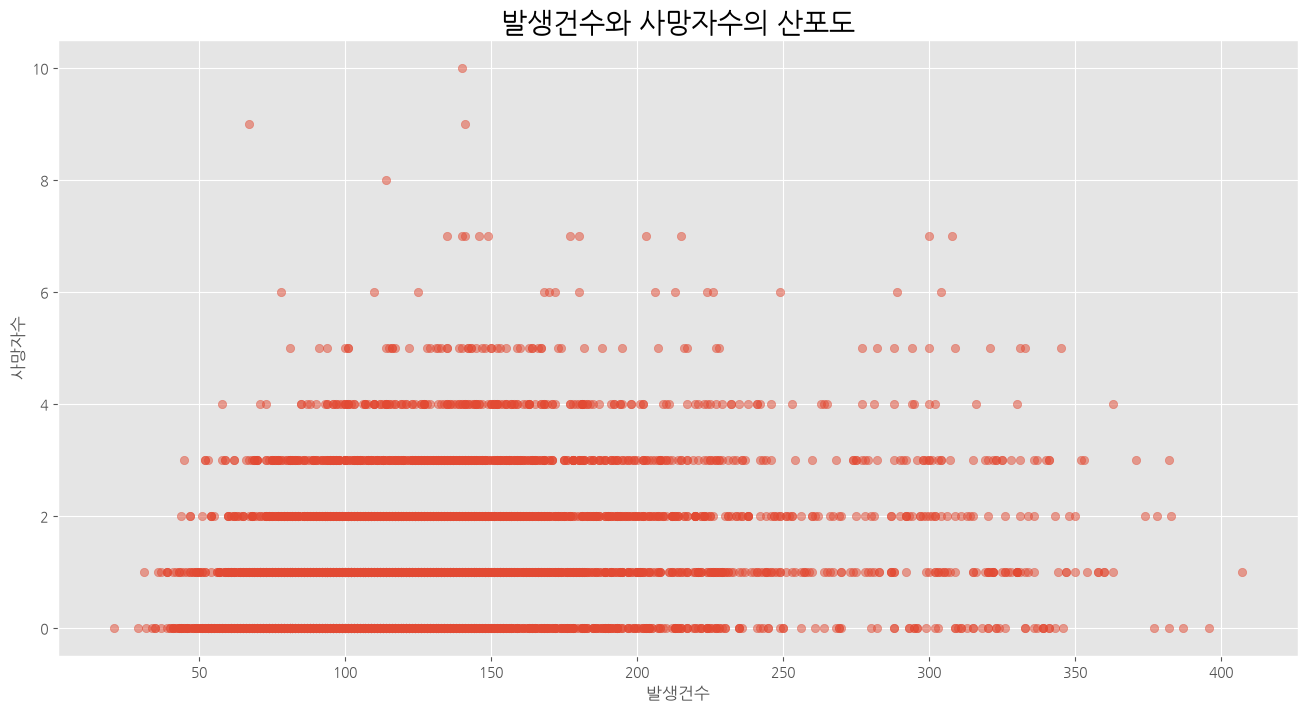

In [25]:
# 발생건수와 사망자수의 산포도 구하기
plt.style.use('ggplot')
plt.figure(figsize=(16, 8))

plt.scatter(
    x=traffic_seoul.발생건수,
    y=traffic_seoul.사망자수,
    alpha=0.5
)

plt.title('발생건수와 사망자수의 산포도', size=20)
plt.xlabel('발생건수')
plt.ylabel('사망자수')

plt.show()

----
### 2019년 데이터 추출

In [26]:
traffic_seoul_2019 = traffic_seoul[traffic_seoul.년도 == 2019]
traffic_seoul_2019.head()

,년도,월,자치구명,발생건수,사망자수,부상자수
4200,2019,1,강남구,281,2,412
4201,2019,1,강동구,98,1,115
4202,2019,1,강북구,88,0,114
4203,2019,1,강서구,136,1,179
4204,2019,1,관악구,104,0,148


In [27]:
# Index 정리
traffic_seoul_2019.reset_index(drop=True, inplace=True)
traffic_seoul_2019.head()

,년도,월,자치구명,발생건수,사망자수,부상자수
0,2019,1,강남구,281,2,412
1,2019,1,강동구,98,1,115
2,2019,1,강북구,88,0,114
3,2019,1,강서구,136,1,179
4,2019,1,관악구,104,0,148


In [28]:
# pivot table로 자치구별 발생건수, 사망자수, 부상자수의 합계를 집계하기
traffic_anal = \
    pd.pivot_table(
        traffic_seoul_2019[['자치구명','발생건수','부상자수', '사망자수']],
        index='자치구명',
        aggfunc='sum'
    )

traffic_anal.head()

,발생건수,부상자수,사망자수
자치구명,,,
강남구,3722,5182,14
강동구,1414,1910,11
강북구,1277,1706,7
강서구,1829,2491,20
관악구,1363,1755,10


In [29]:
# 구청 위도 경도 데이터 불러오기

seoul_limit = pd.read_csv('../Data/seoul.csv', encoding='euc-kr') # utf-8, euc-kr
seoul_limit.columns = ['자치구명', '경도', '위도']
seoul_limit.head()

,자치구명,경도,위도
0,강남구,127.0475,37.51731
1,강동구,127.1238,37.53013
2,강북구,127.0255,37.63975
3,관악구,126.9515,37.47834
4,구로구,126.8875,37.49547


In [30]:
# traffic_anal과 seoul_limit의 병합

data_result = \
pd.merge(
    traffic_anal,
    seoul_limit,
    on='자치구명'
)
data_result.head()

,자치구명,발생건수,부상자수,사망자수,경도,위도
0,강남구,3722,5182,14,127.0475,37.51731
1,강동구,1414,1910,11,127.1238,37.53013
2,강북구,1277,1706,7,127.0255,37.63975
3,강서구,1829,2491,20,126.8496,37.55094
4,관악구,1363,1755,10,126.9515,37.47834


In [31]:
data_result.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   자치구명    25 non-null     object 
 1   발생건수    25 non-null     int64  
 2   부상자수    25 non-null     int64  
 3   사망자수    25 non-null     int64  
 4   경도      25 non-null     float64
 5   위도      25 non-null     float64
dtypes: float64(2), int64(3), object(1)
memory usage: 1.3+ KB


In [37]:
# folium을 사용하기 위해 int를 float로 변환해야 한다.

data_result.발생건수 = data_result.발생건수.astype('float64')
data_result.부상자수 = data_result.부상자수.astype('float64')
data_result.사망자수 = data_result.사망자수.astype('float64')

data_result.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   자치구명    25 non-null     object 
 1   발생건수    25 non-null     float64
 2   부상자수    25 non-null     float64
 3   사망자수    25 non-null     float64
 4   경도      25 non-null     float64
 5   위도      25 non-null     float64
dtypes: float64(5), object(1)
memory usage: 1.3+ KB


In [38]:
data_result.head()

,자치구명,발생건수,부상자수,사망자수,경도,위도
0,강남구,3722.0,5182.0,14.0,127.0475,37.51731
1,강동구,1414.0,1910.0,11.0,127.1238,37.53013
2,강북구,1277.0,1706.0,7.0,127.0255,37.63975
3,강서구,1829.0,2491.0,20.0,126.8496,37.55094
4,관악구,1363.0,1755.0,10.0,126.9515,37.47834


---
### 자치구의 구청을 지도에 표시하기

In [ ]:
# Marker로 구청 위치 표시하기
map = folium.Map(
    location=[37.5502, 126.982],
    zoom_start=11
)

for i in data_result.index:
    popup = folium.Popup(data_result.loc[i,'자치구명'], max_width=200)
    folium.Marker(
        location=[
            data_result.loc[i,'위도'],
            data_result.loc[i,'경도'],
		],
        popup=popup
	).add_to(map)

map

In [42]:
# 교통사고 발생건수를 원형태로 표시하기
map = folium.Map(
    location=[37.5502, 126.982],
    zoom_start=11
)

for i in data_result.index:
    popup = folium.Popup(data_result.loc[i,'자치구명'], max_width=200)
    folium.Marker(
        location=[
            data_result.loc[i,'위도'],
            data_result.loc[i,'경도'],
		],
        popup=popup
	).add_to(map)
    folium.CircleMarker(
        location=[
            data_result.loc[i,'위도'],
            data_result.loc[i,'경도'],
		],
        radius=data_result.loc[i,'발생건수'] / 50        
	).add_to(map)

map

In [43]:
# 교통사고 사망자수를 원형태로 표시하기
map = folium.Map(
    location=[37.5502, 126.982],
    zoom_start=11
)

for i in data_result.index:
    popup = folium.Popup(data_result.loc[i,'자치구명'], max_width=200)
    folium.Marker(
        location=[
            data_result.loc[i,'위도'],
            data_result.loc[i,'경도'],
		],
        popup=popup
	).add_to(map)
    folium.CircleMarker(
        location=[
            data_result.loc[i,'위도'],
            data_result.loc[i,'경도'],
		],
        radius=data_result.loc[i,'발생건수'] / 50        
	).add_to(map)
    folium.CircleMarker(
        location=[
            data_result.loc[i,'위도'],
            data_result.loc[i,'경도'],
		],
        radius=data_result.loc[i,'사망자수'],
        color='red'        
	).add_to(map)

map